### Esercizio 1: classificazione con data augmentation

In [107]:
import tensorflow as tf
import numpy as np
import pathlib
import matplotlib.pyplot as plt

In [108]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url, untar=True)
data_dir = pathlib.Path(data_dir) / 'flower_photos'

Caricamento dataset di training e validation

In [109]:
epochs = 20
seed = 123
img_h = 180
img_w = 180
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=.2,
    subset='training',
    batch_size = batch_size,
    image_size=(img_h, img_w),
    seed=seed
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    batch_size=batch_size,
    image_size=(img_h, img_w),
    seed=seed
)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.


In [110]:
class_names = train_ds.class_names

In [111]:
def plot_samples(dataset):
    #inds = np.random.randint(0, len(dataset), 16)

    plt.figure(figsize=(10,10)) 
    for images, labels in dataset.take(1):
        for i in range(16):
            plt.subplot(4,4,i+1)
            plt.imshow(images[i].numpy().astype(np.uint8))
            plt.title(class_names[labels[i]])
            plt.axis('off')
    
    plt.show()

In [112]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

creazione del modello di classificazione

In [ ]:
model = tf.keras.models.Sequential(
    [
        tf.keras.layers.Input(shape=(img_h, img_w, 3)),
        tf.keras.layers.Rescaling(1./255),
        tf.keras.layers.Conv2D(16,3,padding='same', activation='leaky_relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(32,3,padding='same', activation='leaky_relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(64,3,padding='same', activation='leaky_relu'),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.GlobalAveragePooling2D(), 
        tf.keras.layers.Dropout(0.2),

        tf.keras.layers.Dense(128, activation='leaky_relu'),
        tf.keras.layers.Dense(len(class_names))
    ]
)

model.compile(
    optimizer = 'adam',
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics = ['accuracy']
)

model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_9 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 180, 180, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 90, 90, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 90, 90, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_9      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,549 (127.14 KB)

 Trainable params: 32,549 (127.14 KB)

 Non-trainable params: 0 (0.00 B)

In [114]:
def plot_history(history, epochs):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(epochs)

    plt.figure(figsize=(10,6))
    plt.subplot(1,2,1)
    plt.plot(epochs_range, acc, label='Training accuracy')
    plt.plot(epochs_range, val_acc, label='Validation accuracy')
    plt.grid(True)

    plt.subplot(1,2,2)
    plt.plot(epochs_range, loss, label='Training loss')
    plt.plot(epochs_range, val_loss, label='Validation loss')
    plt.grid(True)

    plt.legend()
    plt.show()

In [115]:
history = model.fit(train_ds, validation_data=val_ds, epochs=epochs)

Epoch 1/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 54ms/step - accuracy: 0.3409 - loss: 1.4579 - val_accuracy: 0.4251 - val_loss: 1.2852
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.4636 - loss: 1.2287 - val_accuracy: 0.4932 - val_loss: 1.1781
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.5201 - loss: 1.1690 - val_accuracy: 0.5232 - val_loss: 1.1505
Epoch 4/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.5317 - loss: 1.1343 - val_accuracy: 0.5123 - val_loss: 1.1345
Epoch 5/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.5484 - loss: 1.0995 - val_accuracy: 0.5599 - val_loss: 1.0786
Epoch 6/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.5661 - loss: 1.0806 - val_accuracy: 0.5559 - val_loss: 1.0941
Epoch 7/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.5708 - loss: 1.0623 - val_accuracy: 0.5531 - val_loss: 1.0603
Epoch 8/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.6025 - loss: 1.0234 - val_accuracy: 0.5967 - v

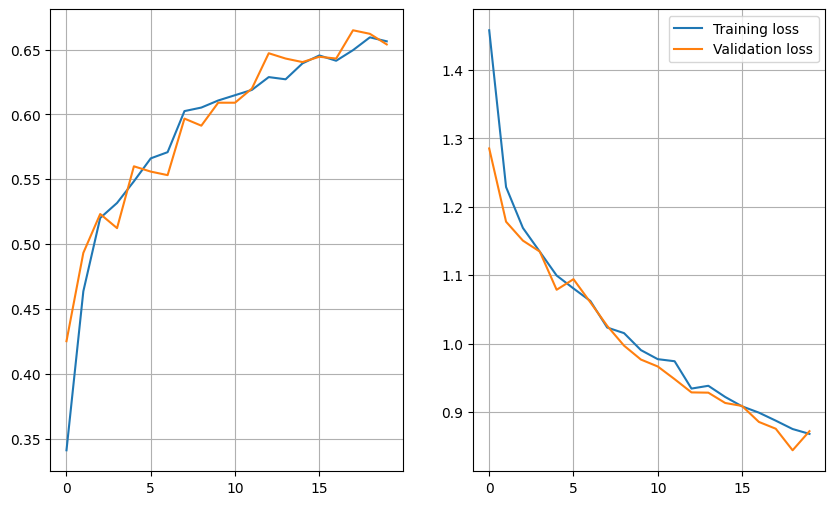

In [116]:
plot_history(history, epochs)

Cosa succede se provo a fare data aug?

In [ ]:
def data_augmentation():
    return tf.keras.models.Sequential([
        tf.keras.layers.RandomFlip('horizontal'),
        tf.keras.layers.RandomRotation(0.1),
        tf.keras.layers.RandomZoom(0.1)
    ])

model = tf.keras.models.Sequential(
    [
        tf.keras.layers.Input(shape=(img_h, img_w, 3)),
        data_augmentation(),
        tf.keras.layers.Rescaling(1./255),
        tf.keras.layers.Conv2D(16,3,padding='same', activation='leaky_relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(32,3,padding='same', activation='leaky_relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(64,3,padding='same', activation='leaky_relu'),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dropout(0.2),

        tf.keras.layers.Dense(128, activation='leaky_relu'),
        tf.keras.layers.Dense(len(class_names))
    ]
)

model.compile(
    optimizer = 'adam',
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics = ['accuracy']
)

model.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_14 (Sequential)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_10 (Rescaling)        │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 180, 180, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 90, 90, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 90, 90, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_10     │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,549 (127.14 KB)

 Trainable params: 32,549 (127.14 KB)

 Non-trainable params: 0 (0.00 B)

In [118]:
history = model.fit(train_ds, validation_data=val_ds, epochs=epochs)

Epoch 1/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 96ms/step - accuracy: 0.3757 - loss: 1.4131 - val_accuracy: 0.4251 - val_loss: 1.3070
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 80ms/step - accuracy: 0.4745 - loss: 1.2271 - val_accuracy: 0.5136 - val_loss: 1.1590
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - accuracy: 0.5037 - loss: 1.1761 - val_accuracy: 0.5245 - val_loss: 1.1483
Epoch 4/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - accuracy: 0.5337 - loss: 1.1366 - val_accuracy: 0.5259 - val_loss: 1.1767
Epoch 5/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - accuracy: 0.5528 - loss: 1.1022 - val_accuracy: 0.5531 - val_loss: 1.1322
Epoch 6/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - accuracy: 0.5647 - loss: 1.0684 - val_accuracy: 0.5136 - val_loss: 1.2333
Epoch 7/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - accuracy: 0.5756 - loss: 1.0697 - val_accuracy: 0.5504 - val_loss: 1.0570
Epoch 8/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 89ms/step - accuracy: 0.6018 - loss: 1.0237 - val_accuracy: 0.5817 - 

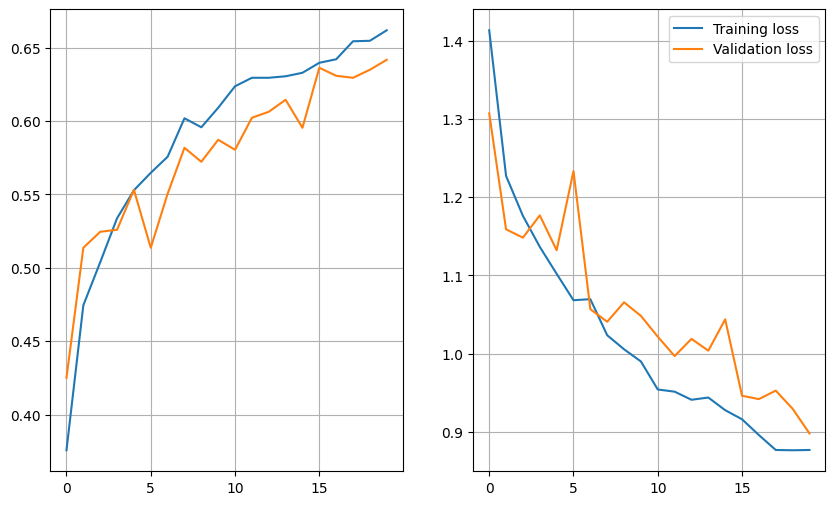

In [119]:
plot_history(history, epochs)